In this section we are going to load the input files for each modality and sample, create a common set of peaks for each sample, create a fragment object for each experiment, generate a peaks x cell matrix for each experiment and finally generate one Seurat object for experiment.

Inputs of this section are the fragments.tsv.gz, metadata.csv and peaks.broadPeak files.
Output of his section is a Seurat object for each experiment (6 in my case just 2 modalities and one sample).
First, load all the required libraries (in Monod load the lib paths for R library and for signac).

In [2]:
.libPaths(c("/home/mattia/miniconda3/envs/Signac/lib/R/library/","/home/mattia/R/x86_64-redhat-linux-gnu-library/4.3/"))

In [3]:
library(Signac)
library(Seurat)
library(GenomicRanges)
library(future)
library(stringr)
library(ggplot2)
library(gghalves)
library(ggpubr)
library(dplyr)
library(tidyverse)
library(EnsDb.Mmusculus.v79)
library(BSgenome.Mmusculus.UCSC.mm10)
library(ComplexUpset)
library(regioneR)
library(scales)
library(ggVennDiagram)

Warning message:
“package ‘Signac’ was built under R version 4.3.2”


Signac built for for SeuratObject v4 was just loaded with SeuratObject
v5; disabling v5 assays and validation routines, and ensuring assays
work in strict v3/v4 compatibility mode

Warning message:
“package ‘Seurat’ was built under R version 4.3.1”
Attaching SeuratObject

‘SeuratObject’ was built with package ‘Matrix’ 1.6.1.1 but the current
version is 1.6.3; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:SeuratObject’:

    intersect


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cb

In [7]:
# directory where the nanoscope repo was cloned
  repodir <- "/home/mattia/nanoscope/" # change accordingly
  source(paste0(repodir,"scripts/functions_scCT.R"))


In [ ]:
#let it first process the RNA

# Read individual replicates
E2_seq_RNA <- Read10X(data.dir = "/date/gcb/gcb_MZ/multiNanoCT/P30156_1004/RNA/cellranger/outs/raw_feature_bc_matrix")
E3_seq_RNA <- Read10X(data.dir = "/date/gcb/gcb_MZ/multiNanoCT/P30156_1005/RNA/cellranger/outs/raw_feature_bc_matrix")
E4_seq_RNA <- Read10X(data.dir = "/date/gcb/gcb_MZ/multiNanoCT/P30156_1006/RNA/cellranger/outs/raw_feature_bc_matrix")

# Create Seurat objects
E2_seq <- CreateSeuratObject(counts = E2_seq_RNA,assay = "RNA", min.cells = 3, min.features = 200)
E3_seq <- CreateSeuratObject(counts = E3_seq_RNA,assay = "RNA", min.cells = 3, min.features = 200)
E4_seq <- CreateSeuratObject(counts = E4_seq_RNA,assay = "RNA", min.cells = 3, min.features = 200)

seuratList <- list(E2_seq, E3_seq, E4_seq)

# Create a for loop to calculate the percentage of mitochondrial genes for each sample
for (i in seq_along(seuratList)) {
  currentSeurat <- seuratList[[i]]
  
  # Calculate percentage of mitochondrial genes
  currentSeurat[["percent.mt"]] <- PercentageFeatureSet(currentSeurat, pattern = "^mt-")
  
  # Print a message indicating the completion of the calculation
  cat("Sample", i, "percent.mt added.\n")
}


In [ ]:
E4_seq

In [ ]:
 VlnPlot( object = E3_seq,
  features = c("nCount_RNA", "nFeature_RNA","percent.mt"),
  ncol = 4,
  pt.size = 0)

In [ ]:
# Assuming you have a list of Seurat objects for each sample
seuratList <- list(E2_seq, E3_seq, E4_seq)


# Visualize QC metrics
for (i in seq_along(seuratList)) {
  # Extract the current Seurat object
  currentSeurat <- seuratList[[i]]
  
  # Create a VlnPlot for QC metrics
  VlnPlot( object = currentSeurat,
  features = c("nCount_RNA", "nFeature_RNA","percent.mt"),
  ncol = 4,
  pt.size = 0)
}



set as wd the output root directory.
Now tha data have ben transfered to date/gcb/V2

In [9]:
wd <- "/date/gcb/gcb_MZ/multiNanoCT/Epi/" # change accordingly
setwd(wd)

set other variables (genome version, assay type, etc) 

In [18]:
# Set the used genome version
genome <- "mm10"
# Genome annotations
genome_ann <- EnsDb.Mmusculus.v79
# BSgenome
bs_genome <- BSgenome.Mmusculus.UCSC.mm10
# Assay (peaks or bins)
assay <- "bins"
# Samples
samples <- dir()
# Modalities
modalities <- dir(samples[1]) # this assumes sample1, sample2, sampleN share the same modalities and barcodes!
# Minimum number of cells a feature must be detected in to be included in the Seurat obj
min_cell <- 1
# Minium number of features a cell must have to be included in the Seurat obj
min_feat <- 1

In order to create one Seurat object for each sample contaning a bin per cell count matrix we need to combine all the input files together. To this end we will need to: i) select the cells that passed internal filtering, ii) get the fragments file reporting the genomic coordinates of each fragment and the reads supporting each fragment and iii) construct a bin x cell matrix from a fragments file.

Load metadata files

First, we parse the metadata file in order to get the cells that passed the filtering and are actually identified as cells.

In [11]:
##### Metadata
# Load metadata for each experiment iterating across the sample list
metadata.ls <- list()
for (smpl in samples) {
  cat("Loading metadata for sample",smpl,"\n")
  for (mod in modalities) {
    cat("\t",mod,"\n")

    # Load metadata
    metadata.ls[[paste0(mod,"_",smpl)]] <- read.csv(paste0(smpl,"/",mod,"/cell_picking/metadata.csv"),
                                                  stringsAsFactors = FALSE)
    rownames(metadata.ls[[paste0(mod,"_",smpl)]]) <- metadata.ls[[paste0(mod,"_",smpl)]]$barcode

 }
}


Loading metadata for sample P29857_1002 
	 ATAC_TATAGCCT 
	 H3K27ac_CCTATCCT 
	 H3K27me3_ATAGAGGC 
Loading metadata for sample P29857_1003 
	 ATAC_TATAGCCT 
	 H3K27ac_CCTATCCT 
	 H3K27me3_ATAGAGGC 
Loading metadata for sample P29857_1004 
	 ATAC_TATAGCCT 
	 H3K27ac_CCTATCCT 
	 H3K27me3_ATAGAGGC 


Here we are going to exclude the cells which have not passed the internal filtering (flagged as passedMB). This internal filtering takes into consideration the log10UMI and the percentage of reads in peaks for each cell and clusterizes the cells based on these values (by building a Gaussian finite mixture mode fitted via EM algorithm via Mclust). This will cluster the cells in n clusters, but only the cells belonging to the top1 cluster with the highest log10UMI will be classified as passedMB=TRUE.

Before doing this, however, we would like to know how many cells we are filtering out:

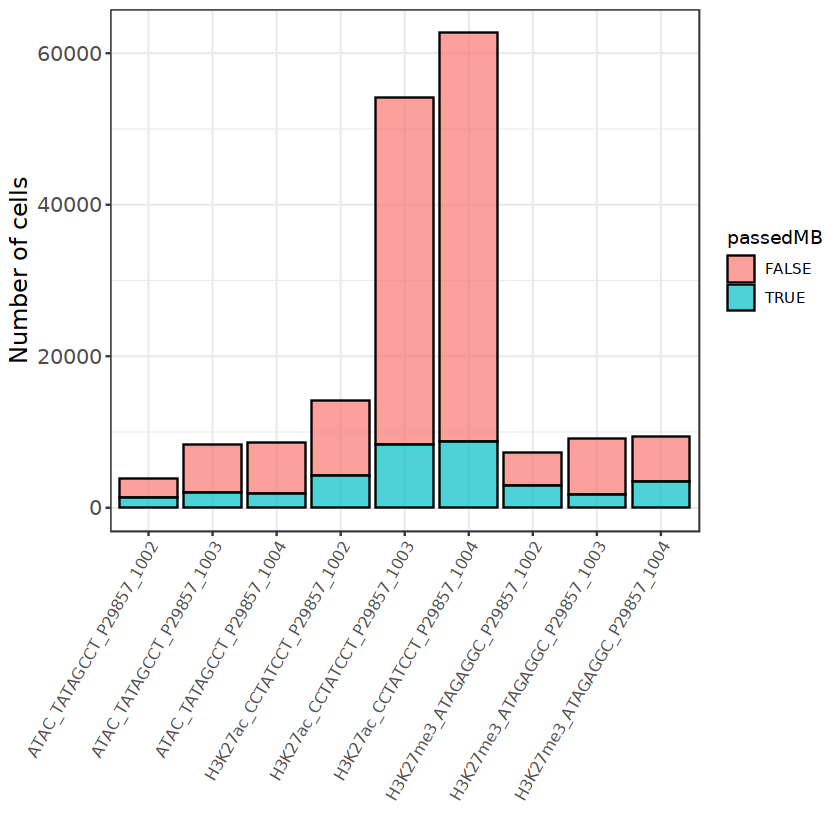

In [12]:
plotPassed(metadata.ls,xaxis_text = 9,angle_x=60)

And which cells we are filtering out:

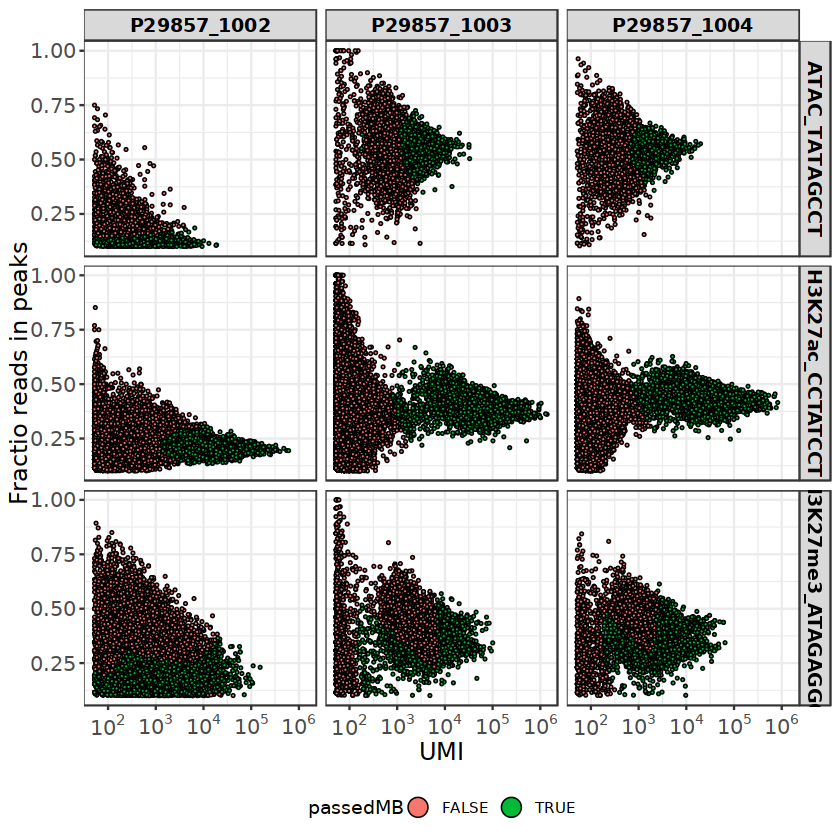

In [13]:
plotPassedCells(metadata.ls,samples,modalities)

In this case, you can see how the cells can be easily clustered in three groups: empty droplets, weird droplets and good cells and how only the good cells are selected. However, if you notice something weird, please, re-do the cell selection by applying some hard cutoffs.

Once we have classified the good cells as passedMB=TRUE, we can proceed with the selection of the good cells only, discarding all the others from further analyses:

In [14]:
metadata.ls <- lapply(metadata.ls, function(x){x[x$passedMB,]})

Load fragments files and creation of fragment objects

Then, we create a fragment object for each experiment (i.e., an object holding all the information related to a single fragment file). To this end we will use the Signac function CreateFragmentObject.

As explained in the Signac vignette, the CreateFragmentObject function checks that the file is present on disk, it is compressed and indexed, computes the MD5 sum for the file and the tabix index so that we can tell if the file is modified at any point, and checks that the expected cells (metadata.csv) are present in the file.

In [15]:
##### Fragments
# Create one fragment object per each experiment iterating across the sample list
fragment.ls <- list()
for (smpl in samples) {
  cat("Loading fragments for sample",smpl,"\n")
  for (mod in modalities) {
    cat("\t",mod,"\n")

    # Load fragments
    fragment.ls[[paste0(mod,"_",smpl)]] <- CreateFragmentObject(
                                              path = paste0(smpl,"/",mod,"/cellranger/outs/fragments.tsv.gz"),
                                              cells = metadata.ls[[paste0(mod,"_",smpl)]]$barcode)

  }
}

Loading fragments for sample P29857_1002 
	 ATAC_TATAGCCT 


Computing hash



	 H3K27ac_CCTATCCT 


Computing hash



	 H3K27me3_ATAGAGGC 


...

Computing hash



	 H3K27ac_CCTATCCT 


Computing hash



	 H3K27me3_ATAGAGGC 


Computing hash



In [16]:
head(fragment.ls[[paste0("ATAC_TATAGCCT_",samples[1])]])

chrom,start,end,barcode,readCount
<chr>,<int>,<int>,<chr>,<int>
chr1,3000621,3000748,GTATCGCTCAACAACA-1,4
chr1,3007614,3007790,TTGTGGCTCCGTAAGG-1,1
chr1,3014477,3014734,GGGTGTGGTGGTTAAG-1,2
chr1,3020970,3021046,GAATGACTCTAAGTCT-1,2
chr1,3027237,3027641,TGTTCACCATTACCCG-1,1
chr1,3027634,3027826,CTTGCTGCACATTGTC-1,4


Then, we select only the cells that have passed internal filtering ( I think this is cellranger filters)



In [ ]:
# Filter the metadata, selecting only cells that have passed internal filtering ("passed_MB")
metadata.ls <- lapply(metadata.ls, function(x){x[x$passedMB,]})

Having loaded the metadta files, we can now create the fragment objects for each experiment.
As explained in the Signac vignette, the CreateFragmentObject function checks that the file is present on disk, it is compressed and indexed, computes the MD5 sum for the file and the tabix index so that we can tell if the file is modified at any point, and checks that the expected cells (metadata.csv) are present in the file.

In [ ]:
##### Fragments
# Create one fragment object per each experiment iterating across the sample list
fragment.ls <- list()
for (smpl in samples) {
  cat("Loading peaks for sample",smpl,"\n")
  for (mod in modalities) {
    cat("\t",mod,"\n")

    # Load fragments
    fragment.ls[[paste0(mod,"_",smpl)]] <- CreateFragmentObject(
                                              path = paste0(smpl,"/",mod,"/cellranger/outs/fragments.tsv.gz"),
                                              cells = metadata.ls[[paste0(mod,"_",smpl)]]$barcode)

  }
}

Check that the data has been created correctly

In [ ]:
head(fragment.ls[[paste0("H3K27ac_TATAGCCT_",samples[1])]]) # put barcode modality of interest

Construct a bin x cell matrix from a fragments file

Now that each experiment has been associated to a fragment object containing fragments and metadata, we can create a bins x cell matrix for each experiment. This will be done by using the Signac function GenomeBinMatrix. GenomeBinMatrix subdivides the genome in non-overlapping windows of length X (X=5kb here) and counts for each bin, for each cell, the number of overlapping fragments.

To speed-up the process, we launch FeatureMatrix with process_n = 20000. This runs OK on our 64GB MacBook Pro, but could go out-of-memory on other systems. If this happens, please, decrease the process_n value (2000 should be fine for every system).


In [19]:


# As usual, append the object to a list
counts.ls <- list()
# Iterate among the experiment names in order to retrieve fragments and cell barcodes from the same experiment
for (experim in names(fragment.ls)) {
  
  cat("Analysing experiment: ",experim,"\n")
  
  # modality name
  modal <- paste0(str_split_fixed(experim,"_",4)[,1],"_",str_split_fixed(experim,"_",4)[,2])
  cat("\tBins from modality: ",modal,"\n")

  # Create FeatureMatrix
  counts.ls[[experim]] <- GenomeBinMatrix(fragments = fragment.ls[[experim]],         # fragments
                                        cells = metadata.ls[[experim]]$barcode,       # metadata
                                        binsize = 5000,                               # bin size
                                        genome = seqlengths(bs_genome),               # chom sizes
                                        process_n = 20000) # the higher, the faster, the more memory is used

}



Analysing experiment:  ATAC_TATAGCCT_P29857_1002 
	Bins from modality:  ATAC_TATAGCCT 


Extracting reads overlapping genomic regions



Analysing experiment:  H3K27ac_CCTATCCT_P29857_1002 
	Bins from modality:  H3K27ac_CCTATCCT 


Extracting reads overlapping genomic regions



Analysing experiment:  H3K27me3_ATAGAGGC_P29857_1002 
	Bins from modality:  H3K27me3_ATAGAGGC 


...

Extracting reads overlapping genomic regions



Analysing experiment:  H3K27ac_CCTATCCT_P29857_1004 
	Bins from modality:  H3K27ac_CCTATCCT 


Extracting reads overlapping genomic regions



Analysing experiment:  H3K27me3_ATAGAGGC_P29857_1004 
	Bins from modality:  H3K27me3_ATAGAGGC 


Extracting reads overlapping genomic regions



In [20]:
counts.ls[[names(fragment.ls)[1]]][3990:4000,1:50]

  [[ suppressing 50 column names 'AAACAAGCATGCAACA-1', 'AAACCGCCAAGCTATG-1', 'AAACCGCCACTCAGTT-1' ... ]]



11 x 50 sparse Matrix of class "dgCMatrix"
                                                                              
chr1-19945001-19950000 . . . . . . . . . . . . . . . . . . . . . . . . . . . .
chr1-19950001-19955000 . . . . . . . . . . . . . . . . . . . . . . . . . . . .
chr1-19955001-19960000 . . . . . . . . . . . . . . . . . . . . . . . . . . . .
chr1-19960001-19965000 . . . . . . . . . . . . . . . . . . . . . . . . . . . .
chr1-19965001-19970000 . . . . . . . . . . . . . . . . . . . . . . . . . . . .
chr1-19970001-19975000 . . . . . . . . . . . . . . . . . . . . . . . . . . . .
chr1-19975001-19980000 . . . . . . . . . . . . . . . . . . . . . . . . . . . .
chr1-19980001-19985000 . . . . . . . . . . . . . . . . . . . . . . . . . . . .
chr1-19985001-19990000 . . . . . . . . . . . . . . . . . . . . . . . . . . . .
chr1-19990001-19995000 . . . . . . . . . . . . . . . . . . . . . . . . . . . .
chr1-19995001-20000000 . . . . . . . . . . . . . . . . . . . . . . . . . . . .
         

1.3 Create one Seurat object for each experiment
Now that we have generated a bins x cell matrix for each experiment, we can store it in a Seurat object along with the fragment object and the metadata.

This is done for each experiment separately, objects will be merged in the next step. The reason for this is that we would like to first perform QC on each experiment individually and then merge all the experiments in a single Seurat object.

In [21]:
obj.ls <- list()
# Iterate among the experiment names in order to retrieve fragments and cell barcodes from the same experiment
for (experim in names(counts.ls)) {

  # Get sample and modality name from the experiment variable
  smpl <- str_split_fixed(experim,"_",3)[,3]
  modality <- str_split_fixed(experim,"_",2)[,1]

  # Create the chromatin assay
  chrom.assay <- CreateChromatinAssay(counts = counts.ls[[experim]],
                                      fragments = fragment.ls[[experim]],
                                      genome = genome,
                                      min.cells = min_cell,
                                      min.features = min_feat)

  # Create the object
  obj.ls[[experim]] <- CreateSeuratObject(counts = chrom.assay,
                                          assay = assay,
                                          meta.data=metadata.ls[[experim]],
                                          project = smpl)

  # Add some metadata of origin
  obj.ls[[experim]]$dataset <- experim
  obj.ls[[experim]]$modality <- modality
  obj.ls[[experim]]$sample <- smpl

}

Before merging the objects, we are going to do some QC on the individual experiments. In particular, we are going to drop cells with abnormal number of UMIs and too low percentage of UMIs overlapping peaks. To define what is “abnormal” and what is not, we will use quantiles. Everything greater than the 95th or less than the 5th quantiles will be here considered as “abnormal” and therefore discarded.

Please, consider how applying these filters is optional and the thresholds used should be specifically set for each dataset as they usually are highly sample-specific. The thresholds we are applying here are quite harsh and, if applied to other datasets, might lead to removal of important biological information.

Please note how we are not here applying any filtering on the TSS enrichment score as while this might be relevant for ATAC it is probably not for H3K27ac and H3K27me3. In case, however, you would like to apply this filtering we recommend to follow Signac’s tutorial on this.

From this step on all the analysis wiull be performed on the single sample experiment



In [22]:
obj.ls.qc <- list()
quant_high <- 0.99
quant_low <- 0.01
for (experiment in names(obj.ls)) {

  # Calculate 5th and 95th quantiles for logUMI
  logUMI_cutoff_high <- quantile(obj.ls[[experiment]]$logUMI, quant_high)
  logUMI_cutoff_low  <- quantile(obj.ls[[experiment]]$logUMI, quant_low)

  # Filter out cells outside these thresholds
  obj.ls.qc[[experiment]] <- subset(obj.ls[[experiment]],
                                    logUMI > logUMI_cutoff_low &
                                      logUMI < logUMI_cutoff_high)

  # print number of discarded cells
  old_n_cell <- nrow(obj.ls[[experiment]][[]])
  new_n_cell <- nrow(obj.ls.qc[[experiment]][[]])
  discarded <- old_n_cell - new_n_cell
  cat(experiment,"\n")
  cat("\tdiscarded",discarded,"cells (",round(discarded/old_n_cell*100,2),"%)\n")
}

ATAC_TATAGCCT_P29857_1002 
	discarded 37 cells ( 2.65 %)
H3K27ac_CCTATCCT_P29857_1002 
	discarded 88 cells ( 2.06 %)
H3K27me3_ATAGAGGC_P29857_1002 
	discarded 77 cells ( 2.57 %)
ATAC_TATAGCCT_P29857_1003 
	discarded 42 cells ( 2.03 %)
H3K27ac_CCTATCCT_P29857_1003 
	discarded 166 cells ( 2 %)
H3K27me3_ATAGAGGC_P29857_1003 
	discarded 35 cells ( 2.06 %)
ATAC_TATAGCCT_P29857_1004 
	discarded 40 cells ( 2.09 %)
H3K27ac_CCTATCCT_P29857_1004 
	discarded 176 cells ( 2 %)
H3K27me3_ATAGAGGC_P29857_1004 
	discarded 70 cells ( 2.03 %)


Warning message:
"The dot-dot notation (`..y..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(y)` instead."


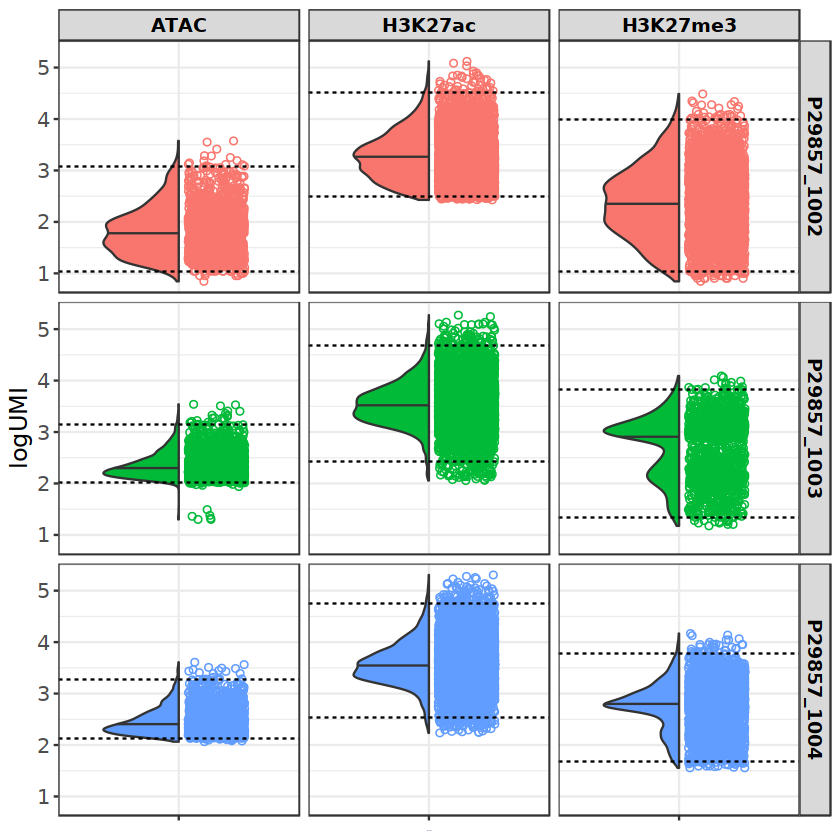

In [23]:
plotCounts(obj = obj.ls, quantiles = c(quant_low,quant_high), feature = "logUMI")

In [24]:
rm(obj.ls)

Number of cells for each sample and modality
Now we can plot, for each sample, the number of cells being simultaneously profiled by all the three modalities. Since we will annotate the cells based on their H3K27ac signal (see 6. Annotation), all the cells lacking the H3K27ac profiling will result as not annotated at the end of the processing of the data. So it is important that the majority of the cells have H3K27ac profiling and that, in general, there is a good overlap among the different modalities.

In [ ]:
# Plot number of cells for each modality for each sample
venn1 <- commonCellHistonMarks(mod1 = obj.ls.qc[[paste0(modalities[1],"_",samples[1])]], 
                               name_mod1 = strsplit(modalities[1],"_")[[1]][1],
                               mod2 = obj.ls.qc[[paste0(modalities[2],"_",samples[1])]], 
                               name_mod2 = gsub("H3","",strsplit(modalities[2],"_")[[1]][1]),
                               mod3 = obj.ls.qc[[paste0(modalities[3],"_",samples[1])]], 
                               name_mod3 = gsub("H3","",strsplit(modalities[3],"_")[[1]][1]),
                               sample = samples[1] )
venn2 <- commonCellHistonMarks(mod1 = obj.ls.qc[[paste0(modalities[1],"_",samples[2])]], 
                               name_mod1 = strsplit(modalities[1],"_")[[1]][1],
                               mod2 = obj.ls.qc[[paste0(modalities[2],"_",samples[2])]], 
                               name_mod2 = gsub("H3","",strsplit(modalities[2],"_")[[1]][1]),
                               mod3 = obj.ls.qc[[paste0(modalities[3],"_",samples[2])]], 
                               name_mod3 = gsub("H3","",strsplit(modalities[3],"_")[[1]][1]),
                               sample = samples[2] )
venn3 <- commonCellHistonMarks(mod1 = obj.ls.qc[[paste0(modalities[1],"_",samples[2])]], 
                               name_mod1 = strsplit(modalities[1],"_")[[1]][1],
                               mod2 = obj.ls.qc[[paste0(modalities[2],"_",samples[2])]], 
                               name_mod2 = gsub("H3","",strsplit(modalities[2],"_")[[1]][1]),
                               mod3 = obj.ls.qc[[paste0(modalities[3],"_",samples[2])]], 
                               name_mod3 = gsub("H3","",strsplit(modalities[3],"_")[[1]][1]),
                               sample = samples[3] ) 

In [ ]:
venn1

In [56]:
combined.obj.ls <- list()
for (mod in modalities) {

  # merge objects among the different samples
  combined.obj.ls[[mod]] <- merge(obj.ls.qc[[paste0(mod,"_",samples[1])]],
                                  y = c(obj.ls.qc[[paste0(mod,"_",samples[2])]],obj.ls.qc[[paste0(mod,"_",samples[3])]]),
                                  add.cell.ids = c(samples[1], samples[2],samples[3]))

}

In [93]:
combined.obj.ls[[modalities[1]]][["bins"]]

ChromatinAssay data with 326096 features for 5263 cells
Variable features: 0 
Genome: mm10 
Annotation present: FALSE 
Motifs present: FALSE 
Fragment files: 3 

In [58]:
combined.obj.ls[[modalities[2]]][["bins"]]

ChromatinAssay data with 502476 features for 20915 cells
Variable features: 0 
Genome: mm10 
Annotation present: FALSE 
Motifs present: FALSE 
Fragment files: 3 

In [59]:
combined.obj.ls[[modalities[3]]][["bins"]]

ChromatinAssay data with 487348 features for 7964 cells
Variable features: 0 
Genome: mm10 
Annotation present: FALSE 
Motifs present: FALSE 
Fragment files: 3 

In [1]:
df1 <- data.frame(cells=sub("^[^_]+_[^_]+_", "",colnames(combined.obj.ls$ATAC_TATAGCCT)))
df2 <- data.frame(cells=sub("^[^_]+_[^_]+_", "",colnames(combined.obj.ls$H3K27ac_CCTATCCT)))
df3<- data.frame(cells=sub("^[^_]+_[^_]+_", "",colnames(combined.obj.ls$H3K27me3_ATAGAGGC)))

df<-inner_join(inner_join(df1,df2),df3)

df

ERROR: Error in eval(expr, envir, enclos): object 'combined.obj.ls' not found


After having filter out low quality cells and having generated one Seurat object per each modality, we can proceed with normalisation and dimensionality reduction. Once again, we will follow Signac vignette.

First, we perform data normalisation. To this end, RunTFIDF will be used. This is a two-step normalisation. procedure, that both normalises across cells to correct for differences in cellular sequencing depth, and across peaks to give higher values to more rare peaks
Second, we select variable features (peaks)
Third, dimension reduction by running singular value decomposition (SVD)

In [ ]:
# Normalisation
obj.ls <- lapply(obj.ls,RunTFIDF)
# a warning (Some features contain 0 total counts) might rise. This is due to the cell filtering performed in the QC step. Should be safe to proceed

# Variable features
obj.ls <- lapply(obj.ls,FindTopFeatures)

# Dim reduction
obj.ls <- lapply(obj.ls,RunSVD)


It usually happens that the first LSI (you can think it as a principal component, if you are more familiar with scrna-seq) is mostly associated to the sequencing depth, rather than biological variation. We will test this by running a modified version of the DepthCor function. The modifications simply consists in plotting the modality name as plot title.

In [ ]:
plot.list <- lapply(obj.ls,DepthCorMulMod)
ggarrange(plot.list[[1]],plot.list[[2]],ncol=2)

Here, the correlation between the first LSI and sequencing depth is quite strong. We will discard it from further analyses. Dimension from 2 will be used.

Then, the dimensionality of the dataset should be determined. Although more sophisticated (and time consuming) methods have been implemented (like the JackStraw procedure), we think that the ‘Elbow plot’ could be informative enough. In the ‘Elbow plot’ the standard deviation explained by each LSI is plotted. When the the plateau is reached, it means that adding more LSI to our analysis does not actually increase the variability explained.



In [ ]:
plot.list_elbow <- lapply(obj.ls,ElbowPlot,reduction = "lsi",ndims = 50)
ggarrange(plot.list_elbow[[1]],plot.list_elbow[[2]],ncol=2)

In this case, we believe that considering the first 40 LSI should be definitely more than enough for all the three modalities (probably even less than 40 should be fine).


Now that we have normalised and found variable features in the data, we can perform graph-based clustering and non-linear dimension reduction for visualization. This is done individually for each modality as different modalities might require different parameters (e.g., number of PCs, clustering resolution, ..).

To find the most appropriate parameter we have used, and suggest using, clustertree.

In [ ]:
# Run dimension reduction and clustering on each modality individually (no ATAC in this case)

# H3K27ac
obj.ls$H3K27ac_TATAGCCT_P29054_2001 <- RunUMAP(obj.ls$H3K27ac_TATAGCCT_P29054_2001,reduction = 'lsi', dims = 2:40)
obj.ls$H3K27ac_TATAGCCT_P29054_2001 <- FindNeighbors(obj.ls$H3K27ac_TATAGCCT_P29054_2001,reduction = 'lsi', dims = 2:40)
obj.ls$H3K27ac_TATAGCCT_P29054_2001 <- FindClusters(obj.ls$H3K27ac_TATAGCCT_P29054_2001, verbose = FALSE, algorithm = 3,resolution = .8)

# H3K27me3
obj.ls$H3K27me3_ATAGAGGC_P29054_2001 <- RunUMAP(obj.ls$H3K27me3_ATAGAGGC_P29054_2001 ,reduction = 'lsi', dims = 2:40)
obj.ls$H3K27me3_ATAGAGGC_P29054_2001  <- FindNeighbors(obj.ls$H3K27me3_ATAGAGGC_P29054_2001 ,reduction = 'lsi', dims = 2:40)
obj.ls$H3K27me3_ATAGAGGC_P29054_2001  <- FindClusters(obj.ls$H3K27me3_ATAGAGGC_P29054_2001 , verbose = FALSE, algorithm = 3,resolution = .8)


In [ ]:
# Plot each modality separately
#p1=DimPlot(combined.obj.ls$ATAC_TATAGCCT, label = TRUE) + NoLegend() +
  #ggtitle("ATAC") +
  #theme(plot.title = element_text(size=15,hjust=0.5,face='bold'))

p1=DimPlot(obj.ls$H3K27ac_TATAGCCT_P29054_2001, label = TRUE) + NoLegend() +
  ggtitle("H3K27ac") +
  theme(plot.title = element_text(size=15,hjust=0.5,face='bold'))

p2=DimPlot(obj.ls$H3K27me3_ATAGAGGC_P29054_2001, label = TRUE) + NoLegend() +
  ggtitle("H3K27me3") +
  theme(plot.title = element_text(size=15,hjust=0.5,face='bold'))

ggarrange(p1,p2,ncol=2)

In [ ]:
p1

In [ ]:
p2

Now that we have identified the different cell states, we need to annotate them, assigning to each of them a biological identity. To this end, we will estimate the activity of each gene by quantifying the number of fragments mapping to its gene body and 2kb upstream the TSS. This will be done by using the Signac function GeneActivity.
Of course, this has to be done on modalities marking transcriptionally active regions. In our case either ATAC or H3K27ac. We believe that H3K27ac is the active modality which might best predict gene activity, thus we will calculate the gene activity scores on nano CUT&Tag H3K27ac modality.
Once again, for most of these processes, we will here follow the Signac vignette.


In [ ]:
# get gene annotations from Ensembl
annotations <- GetGRangesFromEnsDb(ensdb = genome_ann)

# change to UCSC style since the data was mapped to mm10
seqlevelsStyle(annotations) <- 'UCSC'

# add the gene information to the object
Annotation(obj.ls$H3K27ac_TATAGCCT_P29054_2001) <- annotations

Having added the gene annotations, we can calculate the gene activity. This is done by the Signac GeneActivity function that: i) extracts gene coordinates and extends them to include the 2 kb upstream region and ii) counts the number of fragments for each cell that map to each of these regions. Finally, the gene activities are added to the Seurat object as ‘RNA’.

In [ ]:
# Calculate gene activities
gene.activities <- GeneActivity(obj.ls$H3K27ac_TATAGCCT_P29054_2001)

# Add the gene activity matrix to the Seurat object as a new assay
obj.ls$H3K27ac_TATAGCCT_P29054_2001[['RNA']] <- CreateAssayObject(counts = gene.activities)

# normalize RNA data
obj.ls$H3K27ac_TATAGCCT_P29054_2001 <- NormalizeData(
  object = obj.ls$H3K27ac_TATAGCCT_P29054_2001,
  assay = 'RNA',
  normalization.method = 'LogNormalize',
  scale.factor = median(obj.ls$H3K27ac_TATAGCCT_P29054_2001$nCount_RNA)
)

# Set RNA as default assay
DefaultAssay(obj.ls$H3K27ac_TATAGCCT_P29054_2001) <- 'RNA'

By plotting the activities of known canonical marker genes we can get some hints on the biological identities of most of the H3K27ac clusters. Although the signal might sometimes be a bit noisy, already by plotting the gene activity scores we can discriminate some cell states such as astrocytes (telencephalon and non-telencephalon), vascular cells (endothelial, smooth muscle, leptomeningeal cells), oligodendrocytes, neurons (excitatory and inhibitory), microglia, macrophages, Bergmann glia, olfactory ensheating cells and choroid plexus cells.
(These atlases are a great resource to manually annotate your favorite cell state!)
For conciseness, we here opted for a manual annotation, but the probably best practice would be to integrate one of the active nanoCUT&Tag modalities with scRNA-seq data. If interested in doing so, please follow this Signac tutorial.

In [ ]:
#Astrocytes non-telencephalon - AST-NT

FeaturePlot(object = obj.ls$H3K27ac_TATAGCCT_P29054_2001,
  features = c('Sox9'),
  pt.size = 0.1,
  max.cutoff = 'q95',
  ncol = 1,
  label = T)

In [ ]:
#Oligo 

FeaturePlot(
  object = obj.ls$H3K27ac_TATAGCCT_P29054_2001,
  features = c('Mag'),
  pt.size = 0.1,
  max.cutoff = 'q95',
  ncol = 1,
  label = T)

In [ ]:
#Excitatory Neurons

FeaturePlot(
  object = obj.ls$H3K27ac_TATAGCCT_P29054_2001,
  features = c('Slc32a1'),
  pt.size = 0.1,
  max.cutoff = 'q95',
  ncol = 1,
  label = T)

In [ ]:
FeaturePlot(
  object = obj.ls$H3K27ac_TATAGCCT_P29054_2001,
  features = c('Selplg'),
  pt.size = 0.1,
  max.cutoff = 'q95',
  ncol = 1,
  label = T)